In this notebook we use STIXpy and Sunkit-spex to acquire, calibrate and analyse STIX spectra.

In [2]:
# Import Modules

from stixpy.product import Product
from stixpy.coordinates.flare_location import stx_estimate_flare_location

from sunkit_spex.fitting.fitter import Fitter
from sunkit_spex.models.physical.thermal import ThermalEmission
from sunkit_spex.models.physical.nonthermal import ThickTarget
from sunkit_spex.models.physical.albedo import Albedo
from sunkit_spex.models.instrument_response import MatrixModel
from sunkit_spex.models.scaling import InverseSquareFluxScaling

from astropy.time import Time
from astropy import units as u

from sunpy.net import Fido, attrs as a

import os

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

/home/jmitchell/anaconda3/envs/soler_workshop_spectra/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Set-up Download

In [3]:
instrument = a.Instrument.stix
product = a.stix.DataProduct.sci_xray_cpd	

download_dir = './data/'
os.makedirs(download_dir,exist_ok=True)

Download science file 

In [4]:
# Define search parameters
start_time = '2024-03-10T11:00:00'
end_time = '2024-03-10T13:00:00'
time = a.Time(start_time, end_time)

# Search + latest version
resp = Fido.search(instrument, time, product)
sci_table = resp['stix']
sci_table.filter_for_latest_version()
sci_table

2026-06-29 11:40:34 - sunpy - WARNING: SunpyDeprecationWarning: pattern has been replaced with the format keyword. This comes with a new syntax and there is a migration guide available at https://docs.sunpy.org/en/latest/topic_guide/scraper_migration.html.
2026-06-29 11:40:34 - sunpy - WARNING: SunpyDeprecationWarning: pattern has been replaced with the format keyword. This comes with a new syntax and there is a migration guide available at https://docs.sunpy.org/en/latest/topic_guide/scraper_migration.html.


Start Time,End Time,Instrument,Level,DataType,DataProduct,Ver,Request ID
str23,str23,str4,str2,str3,str12,str3,int64
2024-03-10 10:58:52.000,2024-03-10 11:25:32.000,STIX,L1,SCI,sci-xray-cpd,V02,2403107510
2024-03-10 11:32:52.000,2024-03-10 11:38:47.000,STIX,L1,SCI,sci-xray-cpd,V02,2403109509
2024-03-10 11:56:26.000,2024-03-10 12:45:18.000,STIX,L1,SCI,sci-xray-cpd,V02,2403102193
2024-03-10 11:59:06.000,2024-03-10 12:15:40.000,STIX,L1,SCI,sci-xray-cpd,V02,2403109216
2024-03-10 12:43:15.000,2024-03-10 14:10:20.000,STIX,L1,SCI,sci-xray-cpd,V02,2403101620


In [5]:
# Select desired science file from the list and download using Fido.fetch

sci_file_download = Fido.fetch(sci_table[3], path=download_dir)

Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Files Downloaded: 100%|██████████| 1/1 [00:00<00:00,  6.26file/s]


Download background file

In order to find a background file for a specific event the [STIX datacenter](https://datacenter.stix.i4ds.net/ "STIX datacenter") can be used by inputting the science file UID into the search bar and selecting "interactive analysis" from which a suitable background file can be identified. 

For this example a background file has been pre-selected using this method. 

In [6]:
# Define search parameters
start_time_bkg = '2024-03-08T18:00:00'
end_time_bkg = '2024-03-08T21:00:00'
time_bkg = a.Time(start_time_bkg, end_time_bkg)

# Search + latest version
resp_bkg = Fido.search(instrument, time_bkg, product)
bkg_table = resp_bkg['stix']
bkg_table.filter_for_latest_version()
bkg_table

2026-06-29 11:40:41 - sunpy - WARNING: SunpyDeprecationWarning: pattern has been replaced with the format keyword. This comes with a new syntax and there is a migration guide available at https://docs.sunpy.org/en/latest/topic_guide/scraper_migration.html.
2026-06-29 11:40:41 - sunpy - WARNING: SunpyDeprecationWarning: pattern has been replaced with the format keyword. This comes with a new syntax and there is a migration guide available at https://docs.sunpy.org/en/latest/topic_guide/scraper_migration.html.


Start Time,End Time,Instrument,Level,DataType,DataProduct,Ver,Request ID
str23,str23,str4,str2,str3,str12,str3,int64
2024-03-08 18:31:47.000,2024-03-08 18:44:35.000,STIX,L1,SCI,sci-xray-cpd,V02,2403081100
2024-03-08 19:39:15.000,2024-03-08 20:32:35.000,STIX,L1,SCI,sci-xray-cpd,V02,2403087339


In [7]:
bkg_file_download = Fido.fetch(bkg_table[1], path=download_dir)

Files Downloaded: 100%|██████████| 1/1 [00:00<00:00,  6.20file/s]


Read science file as a Product and plot the timeseries for inspection

/home/jmitchell/anaconda3/envs/soler_workshop_spectra/lib/python3.13/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


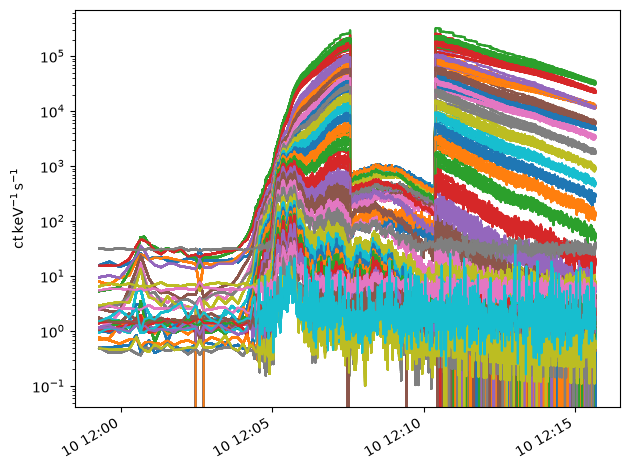

In [8]:
spec_prod = Product(sci_file_download[0])
spec_prod.plot_timeseries()

Now we select a timeframe around the non-thermal peak in order to estimate the flare location. This is required to generate the event specific Spectral Response Matrix (SRM) which is gorrected for the grid transmission.

This uses the STIX imaging software in STIXpy and XRAYVISION to generate an image for a specific time and energy range and identify the brightest pixels  and therefore the flare location.

/home/jmitchell/anaconda3/envs/soler_workshop_spectra/lib/python3.13/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)
2026-06-29T11:43:45Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-15.80897522  86.32321167]] arcsec
2026-06-29 11:43:45 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-15.80897522  86.32321167]] arcsec
2026-06-29T11:43:45Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-15.80897522  86.32321167]] arcsec
2026-06-29 11:43:45 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-15.80897522  86.32321167]] arcsec
2026-06-29T11:43:45Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-15.80897522  86.32321167]] arcsec
2026-06-29 11:43:45 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-15.80897522  86.32321167]] arcsec
2026-06-29T11:43:45Z INFO stixpy.coordinates.transforms

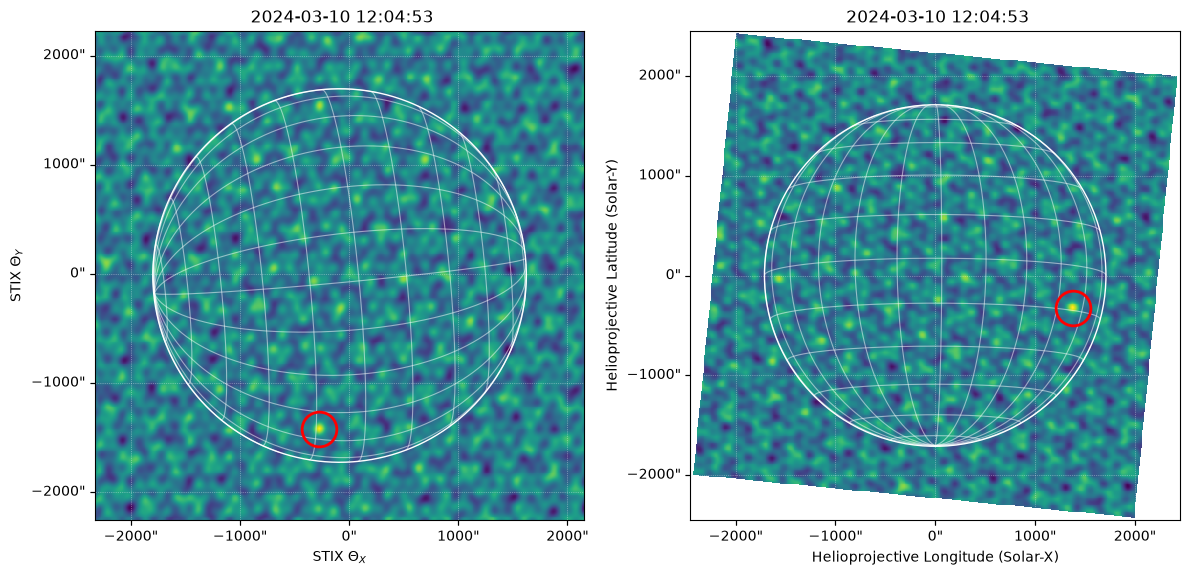

<SkyCoord (Helioprojective: obstime=2024-03-10T12:04:53.495, rsun=695700.0 km, observer=<HeliographicStonyhurst Coordinate (obstime=2024-03-10T12:04:53.495, rsun=695700.0 km): (lon, lat, radius) in (deg, deg, m)
    (-17.19421071, -5.76313864, 8.38588645e+10)>): (Tx, Ty, distance) in (arcsec, arcsec, )
    (1381.51282385, -323.5457191, 1.)>
<SkyCoord (STIXImaging: obstime=2024-03-10T12:04:06.395, obstime_end=2024-03-10T12:05:40.595, observer=<HeliographicStonyhurst Coordinate (obstime=2024-03-10T12:04:53.495, rsun=695700.0 km): (lon, lat, radius) in (deg, deg, m)
    (-17.19421071, -5.76313864, 8.38588645e+10)>, rsun=695700.0 km): (Tx, Ty) in arcsec
    (-274.7133152, -1422.14026735)>


In [16]:
t_range = [Time(spec_prod.meta['DATE-BEG'])+5*u.min,Time(spec_prod.meta['DATE-END'])-10*u.min]
t_cent =  spec_prod.meta['DATE-AVG']

flare_location= stx_estimate_flare_location(sci_file_download[0], t_range, plot=True)

flare_location_hpc = flare_location['hpc']
flare_location_stx = flare_location['stx']


print(flare_location_hpc)
print(flare_location_stx)

Now use the flare location generated above to create the event specific SRM

In [21]:
srm_dat = spec_prod.get_masked_srm(flare_location=flare_location)

edges =  [  5.   6.   7.   8.   9.  10.  11.  12.  13.  14.  15.  16.  18.  20.
  22.  25.  28.  32.  36.  40.  45.  50.  56.  63.  70.  76.  84. 100.
 120. 150.  nan]
edges =  [  5.   6.   7.   8.   9.  10.  11.  12.  13.  14.  15.  16.  18.  20.
  22.  25.  28.  32.  36.  40.  45.  50.  56.  63.  70.  76.  84. 100.
 120. 150.  nan]
edgeslow =  [  4.   5.   6.   7.   8.   9.  10.  11.  12.  13.  14.  15.  16.  18.
  20.  22.  25.  28.  32.  36.  40.  45.  50.  56.  63.  70.  76.  84.
 100. 120. 150.]
drm =  (3230, 3230)
drm_clipped_1 =  (3230, 3230)
drm_clipped =  (3230, 3230)
drm_new =  (3230, 30)


Create backgroud data product

In [23]:
bkg = Product(bkg_file_download[0])

Now we specify a time range between which we shall integrate and perform a spectral fit. 

To generate a calibrated, background subtracted spectrum for the desired time period, we must provide a time range, a spectral response matrix, a background data product, and a flare location to `get_spec_obj` this will then result in a Sunkit-spex spectrum object that can be passed to the Sunkit-spex fitter. 

In [22]:
t_range = ["2024-03-10T12:05:55","2024-03-10T12:06:00"]

spectrum = spec_prod.get_spec_obj(event_time_range=t_range,
                             srm_dictionary=srm_dat,
                             bkg_data=bkg,
                             flare_location=flare_location)

/home/jmitchell/anaconda3/envs/soler_workshop_spectra/lib/python3.13/site-packages/erfa/core.py:133: ErfaWarning: ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"
  warn(f'ERFA function "{func_name}" yielded {wmsg}', ErfaWarning)


[ 0  1  2  3  4  5  6  7 13 14 15 19 20 21 22 23 24 25 26 27 28 29 30 31]
(24,)
[0 1 2 3 4 5 6 7]
(8,)


2026-06-29 11:53:44 - sunpy - WARNING: SunpyDeprecationWarning: pattern has been replaced with the format keyword. This comes with a new syntax and there is a migration guide available at https://docs.sunpy.org/en/latest/topic_guide/scraper_migration.html.
2026-06-29 11:53:44 - sunpy - WARNING: SunpyDeprecationWarning: pattern has been replaced with the format keyword. This comes with a new syntax and there is a migration guide available at https://docs.sunpy.org/en/latest/topic_guide/scraper_migration.html.


var_shape_check =  (1325, 24, 8, 30)


Files Downloaded: 100%|██████████| 1/1 [00:00<00:00,  8.39file/s]
2026-06-29T11:53:44Z INFO stixpy.coordinates.transforms 141: Using SAS pointing: [[-15.68892162  85.92653947]] arcsec
2026-06-29 11:53:44 - stixpy.coordinates.transforms - INFO: Using SAS pointing: [[-15.68892162  85.92653947]] arcsec


ct_de =  (30,)
cts_axis =  (31,)


Now we can use the srm and the spectrum object to plot the SRM

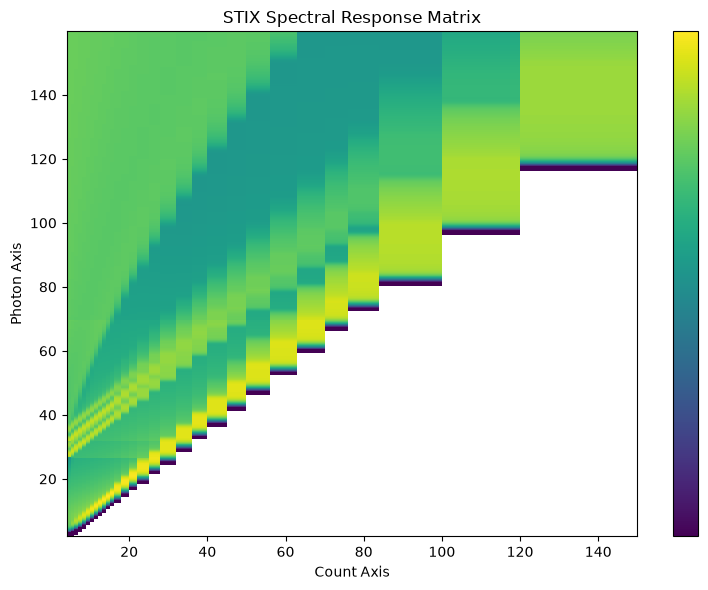

In [24]:
srm_plot = srm_dat['srm']
ph_axis = srm_dat['ph_axis']
ct_axis = spectrum.spectral_axis.bin_edges.value

fig, ax = plt.subplots(figsize=(8, 6))

mesh = ax.pcolormesh(ct_axis, ph_axis, srm_plot, cmap="viridis", norm=LogNorm(vmin=1e-11, vmax=srm_plot.max()))

cbar = fig.colorbar(mesh, ax=ax)
cbar.set_ticks([])
ax.set_xlabel("Count Axis")
ax.set_ylabel("Photon Axis")
ax.set_title("STIX Spectral Response Matrix")

plt.tight_layout()
plt.show()

Define the desired model components using Sunkit-spex models built around the Astropy modeling API. 

For this example we use three physical model components, `Thermal`,  non-thermal `ThickTarget` and `Albedo`.

The `Thermal` model decribes the thermal emission observed in the soft X-ray regime originating in the corona. 

The `ThickTarget` model represents the non thermal bremsstrahlung radiation emitted in the hard X-rays caused by flare accelerated electrons, precipitating down from the corona impacting the denser layers of the chromosphere.

The `Albedo` model component represents the re-processed X-ray emission  from compton backscattering on the solar surface. 

We also include an `InverseSquareFluxScaling` model component to account for the space-craft distance from the sun, and an  `MatrixModel` which uses the event specific SRM to convert the physical model from physical photon fluxes to an instrument specific count flux that can then be compared to the data during the forward fitting process.  

In [28]:
model = (((ThermalEmission() + ThickTarget()) | Albedo()) * InverseSquareFluxScaling() ) | MatrixModel()


We can access the fittable parameters of the compound model

In [29]:
model.param_names

('temperature_0',
 'emission_measure_0',
 'mg_0',
 'al_0',
 'si_0',
 's_0',
 'ar_0',
 'ca_0',
 'fe_0',
 'p_1',
 'break_energy_1',
 'q_1',
 'low_e_cutoff_1',
 'high_e_cutoff_1',
 'total_eflux_1',
 'theta_2',
 'anisotropy_2',
 'observer_distance_3',
 'conversion_factor_4')

It is now possible to set boundaries for these parameters, and free and fix them. It is important to pass the correct units if setting parameter values or limits

In [30]:
model.break_energy_1 =1500*u.keV
model.break_energy_1.fixed = True
model.total_eflux_1.fixed = False
model.low_e_cutoff_1.min=8*u.keV
model.low_e_cutoff_1.max=60*u.keV

In [15]:
fitter = Fitter(model=model,
                spectrum_object=spectrum)

In [16]:
fitter.fit_range = [4.5*u.keV, 85*u.keV]

In [17]:
fitter._spectrum_object.__dict__

{'_spectral_axis_index': 0,
 '_spectral_axis': <SpectralAxis [  4.5,   5.5,   6.5,   7.5,   8.5,   9.5,  10.5,  11.5,  12.5,  13.5,
     14.5,  15.5,  17. ,  19. ,  21. ,  23.5,  26.5,  30. ,  34. ,  38. ,
     42.5,  47.5,  53. ,  59.5,  66.5,  73. ,  80. ,  92. , 110. , 135. ] keV>,
 '_data': array([1.87940680e+04, 4.24137524e+04, 1.37484459e+05, 9.94586799e+04,
        5.83730671e+04, 3.53715427e+04, 2.44727750e+04, 1.71312870e+04,
        1.21454276e+04, 8.57814833e+03, 6.36081226e+03, 4.86248577e+03,
        6.91019909e+03, 4.73339635e+03, 3.39760017e+03, 3.96946793e+03,
        2.63509794e+03, 2.30810076e+03, 1.50984127e+03, 1.05682459e+03,
        1.06029680e+03, 7.67015841e+02, 7.02210279e+02, 6.48743198e+02,
        4.73002476e+02, 2.11612478e+02, 1.69338954e+02, 2.08140725e+02,
        1.43691185e+02, 1.08581953e+02]),
 '_mask': array([False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        

In [18]:
fitter._spectrum_object.meta['distance']
fitter._spectrum_object.meta['angle']

<Quantity 53.19306156 deg>

In [19]:
fitter.model.fixed

{'temperature_0': False, 'emission_measure_0': False, 'mg_0': True, 'al_0': True, 'si_0': True, 's_0': True, 'ar_0': True, 'ca_0': True, 'fe_0': True, 'p_1': False, 'break_energy_1': True, 'q_1': True, 'low_e_cutoff_1': False, 'high_e_cutoff_1': True, 'total_eflux_1': False, 'theta_2': False, 'anisotropy_2': True, 'observer_distance_3': True, 'conversion_factor_4': True}

In [20]:
fitter.do_fit()

/home/jmitchell/anaconda3/envs/soler_workshop_spectra/lib/python3.13/site-packages/sunkit_spex/models/physical/thermal.py:1273: UserWarning: Some input energy values outside valid range of 1.0002920302956426--10.34753795157738 keV. Flux will be zero outside this range.
  warnings.warn(message)


In [21]:
print(fitter.fitted_model)

Model: CompoundModel
Inputs: ('x',)
Outputs: ('y',)
Model set size: 1
Expression: ([0] + [1] | [2]) * [3] | [4]
Components: 
    [0]: <ThermalEmission(temperature=20.18098588 MK, emission_measure=0.24696015 1 / cm3, mg=8.15, al=7.04, si=8.1, s=7.27, ar=6.58, ca=6.93, fe=8.1, name='ThermalEmission')>

    [1]: <ThickTarget(p=3.84721453, break_energy=1500. keV, q=5., low_e_cutoff=17.4370789 keV, high_e_cutoff=1500. keV, total_eflux=4.8310321 electron / s, name='ThickTarget')>

    [2]: <Albedo(theta=53.19306156 deg, anisotropy=1., name='Albedo')>

    [3]: <InverseSquareFluxScaling(observer_distance=0.5605425 AU, name='InverseSquareFluxScaling')>

    [4]: <MatrixModel(conversion_factor=1., name='SRM')>
Parameters:
      temperature_0     emission_measure_0 ... conversion_factor_4
            MK               1 / cm3       ...                    
    ------------------ ------------------- ... -------------------
    20.180985880980206 0.24696014709078937 ...                 1.0


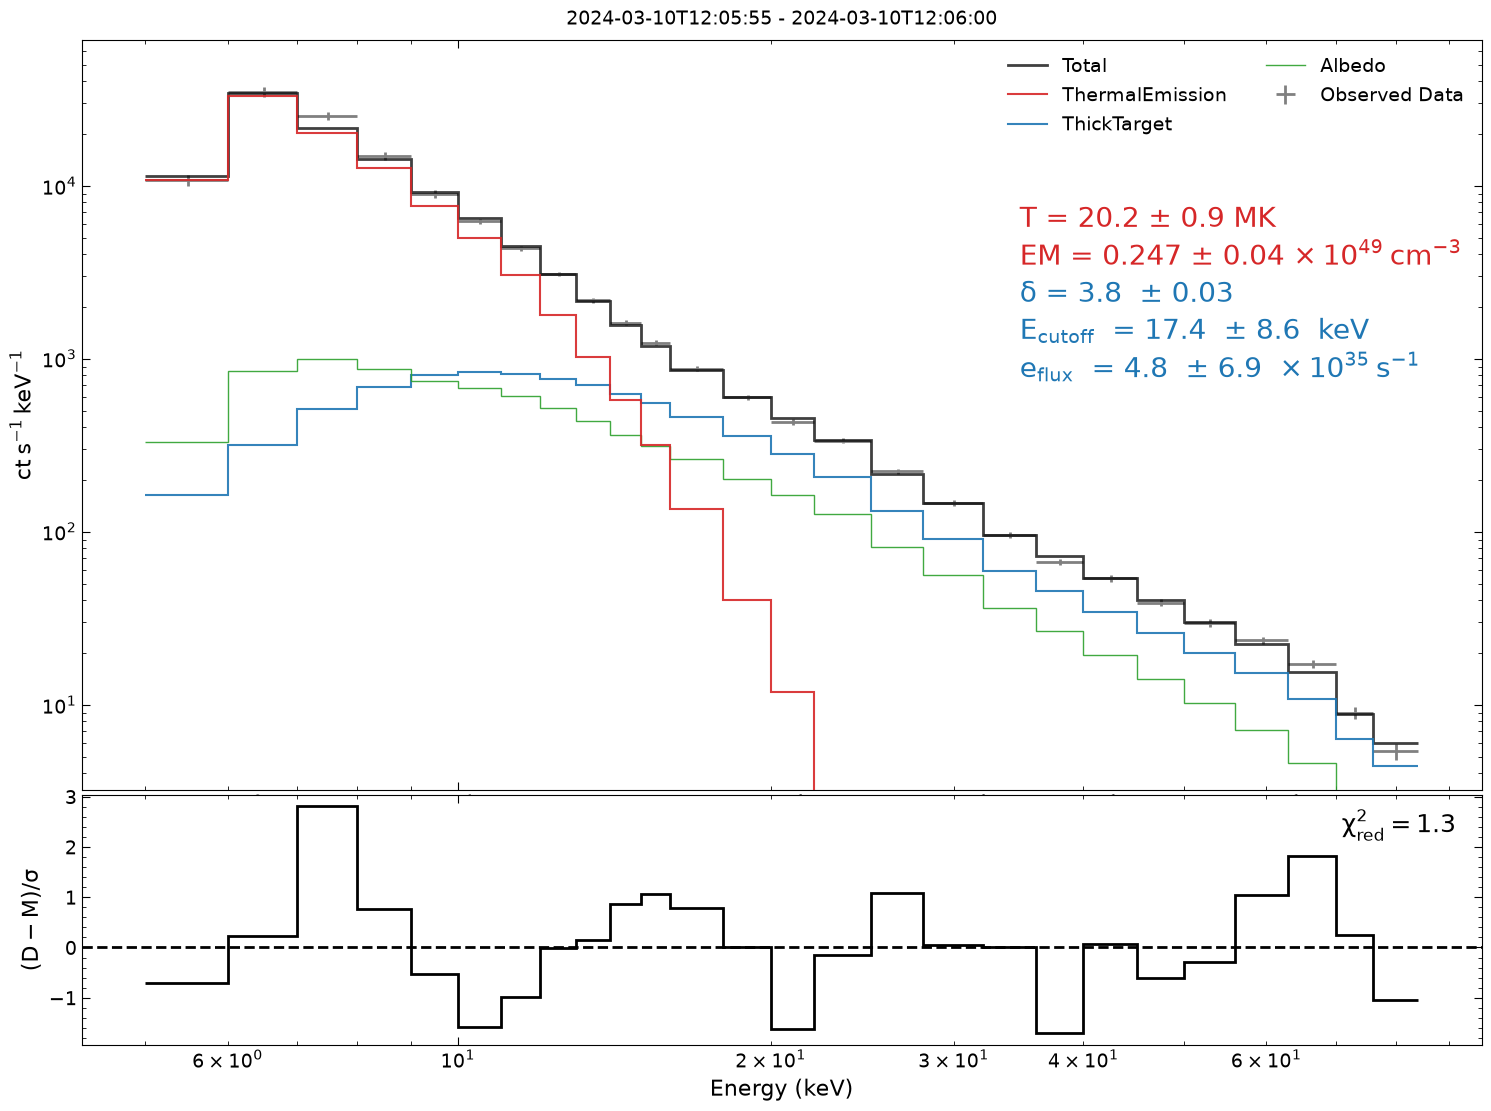

In [23]:
fitter.plot_fit_results()